In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Implement spectral decomposition

In [2]:
def spectral_decomposition(a):
    # Compute eigenvalues and eigenvectors
    eigen_values, eigen_vectors = np.linalg.eig(a)

    # Construct diagonal matrix of eigenvalues
    lambda_mat = np.diag(eigen_values)

    # Reconstruct matrix: A = Q * Lambda_mat * Q^(-1)
    q = eigen_vectors
    q_inv = np.linalg.inv(q)
    mat_reconstructed = q @ lambda_mat @ q_inv

    return eigen_values, eigen_vectors, mat_reconstructed

# Test with 2x2 matrix
A_2x2 = np.array([[4, 2],
                  [1, 3]])

print("=" * 60)
print("SPECTRAL DECOMPOSITION")
print("=" * 60)
print(f"Original Matrix A:\n{A_2x2}\n")

eigen_values, eigen_vectors, mat_reconstructed = spectral_decomposition(A_2x2)

print(f"Eigenvalues:\n{eigen_values}\n")
print(f"Eigenvectors (columns):\n{eigen_vectors}\n")
print(f"Reconstructed Matrix:\n{mat_reconstructed}\n")
print(f"Reconstruction Error (Frobenius norm): {np.linalg.norm(A_2x2 - mat_reconstructed):.2e}")
print(f"Verification: Matrices match? {np.allclose(A_2x2, mat_reconstructed)}")

SPECTRAL DECOMPOSITION
Original Matrix A:
[[4 2]
 [1 3]]

Eigenvalues:
[5. 2.]

Eigenvectors (columns):
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]

Reconstructed Matrix:
[[4. 2.]
 [1. 3.]]

Reconstruction Error (Frobenius norm): 1.09e-15
Verification: Matrices match? True


## Visualization of Eigenvectors

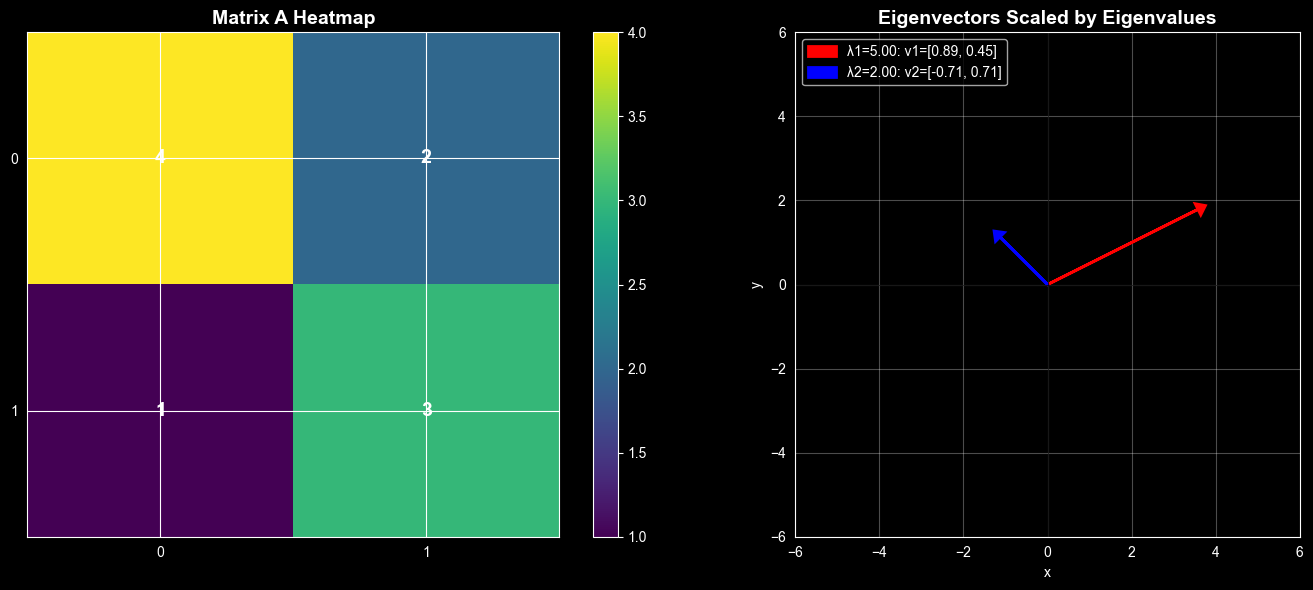


VISUALIZATION COMPLETE
Saved to: task2_eigenvectors_2d.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap of matrix A
ax1 = axes[0]
im = ax1.imshow(A_2x2, cmap='viridis', aspect='auto')
ax1.set_title('Matrix A Heatmap', fontsize=14, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{A_2x2[i, j]}', ha='center', va='center',
                color='white', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax1)

# Eigenvectors visualization
ax2 = axes[1]
ax2.set_xlim(-6, 6)
ax2.set_ylim(-6, 6)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# Plot eigenvectors scaled by eigenvalues
colors = ['red', 'blue']
for i in range(len(eigen_values)):
    vec = eigen_vectors[:, i]
    val = eigen_values[i]
    # Scale vector by eigenvalue for visibility
    scaled_vec = vec * abs(val) * 0.8

    ax2.arrow(0, 0, scaled_vec[0], scaled_vec[1],
              head_width=0.3, head_length=0.2,
              fc=colors[i], ec=colors[i], linewidth=2,
              label=f'λ{i+1}={val:.2f}: v{i+1}=[{vec[0]:.2f}, {vec[1]:.2f}]')

ax2.set_title('Eigenvectors Scaled by Eigenvalues', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
output_dir = Path.cwd() / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "task2_eigenvectors_2d.png"
plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("VISUALIZATION COMPLETE")
print("Saved to: task2_eigenvectors_2d.png")
print("=" * 60)
